<a href="https://colab.research.google.com/github/NAHIN-JZS/Image-processing-works/blob/main/Image_Segmentation_using_kmeans_and_mean_shift.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, csv
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import color as skcolor
from skimage.segmentation import find_boundaries, relabel_sequential
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.optimize import linear_sum_assignment
from scipy.ndimage import distance_transform_edt, binary_dilation, label as cc_label

In [ ]:
def load_image(path, resize_half=True):
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if resize_half:
        img = cv2.resize(img, (img.shape[1] // 2, img.shape[0] // 2),
                         interpolation=cv2.INTER_AREA)
    return img

def load_gt_mask(path, resize_to=None):
    gt = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if resize_to is not None:                       # match image size if you resized it
        gt = cv2.resize(gt, (resize_to[1], resize_to[0]),
                        interpolation=cv2.INTER_NEAREST)
    out = np.zeros_like(gt, dtype=np.int32)         # remap arbitrary gray values -> 0,1,2,...
    for new_id, v in enumerate(np.unique(gt)):
        out[gt == v] = new_id
    return out

In [ ]:
def color_features(img, space='rgb'):
    img_f = img.astype(np.float32) / 255.0
    if space == 'rgb':
        feat = img_f
    elif space == 'lab':
        feat = skcolor.rgb2lab(img_f)
    elif space == 'hsv':
        feat = skcolor.rgb2hsv(img_f)
    else:
        raise ValueError(space)
    return feat.reshape(-1, 3)

In [ ]:
def spatial_features(shape):
    h, w = shape[:2]
    ys, xs = np.mgrid[0:h, 0:w]
    xs = xs.astype(np.float32) / w
    ys = ys.astype(np.float32) / h
    return np.stack([xs.ravel(), ys.ravel()], axis=1)

In [ ]:
def build_gabor_bank(ksize=21, n_orient=4, scales=(3.0, 6.0)):
    bank, meta = [], []
    for sigma in scales:
        lambd = sigma * 2.0                          # wavelength tied to scale
        for t in range(n_orient):
            theta = t * np.pi / n_orient
            k = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd,
                                   gamma=0.5, psi=0, ktype=cv2.CV_32F)
            k -= k.mean()                            # zero-mean -> ignores flat brightness
            bank.append(k); meta.append((sigma, np.degrees(theta)))
    return bank, meta

def gabor_responses(img, bank):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    resp = [np.abs(cv2.filter2D(gray, cv2.CV_32F, k)) for k in bank]
    return np.stack(resp, axis=-1)                   # H x W x n_filters

def texture_features(img, bank):
    resp = gabor_responses(img, bank)
    return resp.reshape(-1, resp.shape[-1]), resp

In [ ]:
def show_gabor_bank(bank, meta, cols=4):
    n = len(bank); rows = int(np.ceil(n / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))
    for i, a in enumerate(np.ravel(ax)):
        if i < n:
            a.imshow(bank[i], cmap='gray')
            a.set_title(f"s={meta[i][0]:.0f}, {meta[i][1]:.0f} deg", fontsize=8)
        a.axis('off')
    plt.tight_layout(); plt.show()

def show_gabor_responses(img, bank, meta, cols=4):
    resp = gabor_responses(img, bank)
    n = resp.shape[-1]; rows = int(np.ceil(n / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))
    for i, a in enumerate(np.ravel(ax)):
        if i < n:
            r = resp[..., i]
            r = (r - r.min()) / (r.max() - r.min() + 1e-9)   # version-safe normalize
            a.imshow(r, cmap='jet'); a.set_title(f"{meta[i][1]:.0f} deg", fontsize=8)
        a.axis('off')
    plt.tight_layout(); plt.show()

In [ ]:
def build_feature_space(img, use_color=None, use_spatial=False,
                        use_texture=False, gabor_bank=None, spatial_weight=1.0):
    blocks = []
    if use_color:
        blocks.append(StandardScaler().fit_transform(color_features(img, use_color)))
    if use_texture:
        tex, _ = texture_features(img, gabor_bank)
        blocks.append(StandardScaler().fit_transform(tex))
    if use_spatial:
        sp = StandardScaler().fit_transform(spatial_features(img.shape))
        blocks.append(sp * spatial_weight)
    if not blocks:
        raise ValueError("Select at least one feature type.")
    return np.concatenate(blocks, axis=1)

In [ ]:
def reduce_pca(feat, var=0.95):
    p = PCA(n_components=var, svd_solver='full')
    return p.fit_transform(feat), p.n_components_

In [ ]:
def segment_kmeans(feat, shape, k=5, seed=42):
    labels = KMeans(n_clusters=k, random_state=seed, n_init=10).fit_predict(feat)
    return labels.reshape(shape[:2])

In [ ]:
def _kernel_weights(d2, h, kernel):
    if kernel == 'gaussian':
        return np.exp(-0.5 * d2 / (h * h))
        # print("h  ", h)
        # print("d2  ", d2.shape)
        # return cv2.getGaussianKernel(h, d2)
    elif kernel == 'epanechnikov':
        w = 1.0 - d2 / (h * h)
        w[w < 0] = 0.0
        return w
    raise ValueError(kernel)

def segment_meanshift(feat, shape, bandwidth, kernel='gaussian',
                      max_iter=50, tol=1e-3, n_ref=2000, seed=0):
    X = feat.astype(np.float32)
    rng = np.random.default_rng(seed)
    ref = X[rng.choice(X.shape[0], n_ref, replace=False)] if X.shape[0] > n_ref else X
    radius = bandwidth * (3.0 if kernel == 'gaussian' else 1.0)   # gaussian truncated at 3h
    nn = NearestNeighbors(radius=radius).fit(ref)

    seeds = np.unique(np.round(ref / bandwidth), axis=0) * bandwidth   # bin-seeding

    for _ in range(max_iter):
        moved = 0.0
        nbrs = nn.radius_neighbors(seeds, return_distance=False)
        new = seeds.copy()
        for i, idx in enumerate(nbrs):
            if len(idx) == 0:
                continue
            pts = ref[idx]
            d2 = np.sum((pts - seeds[i]) ** 2, axis=1)
            w = _kernel_weights(d2, bandwidth, kernel)
            if w.sum() < 1e-12:
                continue
            m = (pts * w[:, None]).sum(0) / w.sum()
            moved = max(moved, np.linalg.norm(m - seeds[i]))
            new[i] = m
        seeds = new
        if moved < tol:
            break

    # merge converged seeds into distinct modes
    modes, mode_ids = [], np.zeros(len(seeds), np.int32)
    merge_r = bandwidth * 0.5
    for i, s in enumerate(seeds):
        found = -1
        for j, m in enumerate(modes):
            if np.linalg.norm(s - m) < merge_r:
                found = j; break
        if found == -1:
            modes.append(s); mode_ids[i] = len(modes) - 1
        else:
            mode_ids[i] = found
    modes = np.array(modes)

    _, lab = NearestNeighbors(n_neighbors=1).fit(modes).kneighbors(X)
    return lab.ravel().reshape(shape[:2])

In [ ]:
from skimage.filters.rank import modal
from skimage.morphology import disk

def postprocess_simple(label_img, radius=5, passes=2):
    out = label_img.astype('uint8')
    for _ in range(passes):
        out = modal(out, disk(radius))
    return out.astype(np.int32)

In [ ]:
def match_labels(pred, gt):
    out = pred.copy()
    for p in np.unique(pred):
        out[pred == p] = np.bincount(gt[pred == p]).argmax()
    return out

In [ ]:
def confusion_matrix_norm(pred, gt):
    ids = np.unique(gt); idx = {v: i for i, v in enumerate(ids)}
    cm = np.zeros((len(ids), len(ids)))
    for g in ids:
        for p in ids:
            cm[idx[g], idx[p]] = np.sum((gt == g) & (pred == p))
    row = cm.sum(1, keepdims=True); row[row == 0] = 1
    return cm / row, ids

def per_class_metrics(pred, gt):
    rows = []
    for c in np.unique(gt):
        tp = np.sum((pred == c) & (gt == c))
        fp = np.sum((pred == c) & (gt != c))
        fn = np.sum((pred != c) & (gt == c))
        prec = tp / (tp + fp) if tp + fp else 0
        rec  = tp / (tp + fn) if tp + fn else 0
        iou  = tp / (tp + fp + fn) if tp + fp + fn else 0
        rows.append((c, prec, rec, iou))
    return rows

def bf_score(pred, gt, tol=2):
    scores, ids = [], np.unique(gt)
    for c in ids:
        pb = find_boundaries(pred == c, mode='inner')
        gb = find_boundaries(gt == c, mode='inner')
        if pb.sum() == 0 and gb.sum() == 0:
            scores.append(1.0); continue
        if pb.sum() == 0 or gb.sum() == 0:
            scores.append(0.0); continue
        d_gt, d_pred = distance_transform_edt(~gb), distance_transform_edt(~pb)
        prec = np.mean(d_gt[pb] <= tol)
        rec  = np.mean(d_pred[gb] <= tol)
        scores.append(2 * prec * rec / (prec + rec) if prec + rec else 0)
    return np.array(scores), ids

In [ ]:
def label_to_color(label_img):
    rng = np.random.default_rng(0)
    out = np.zeros((*label_img.shape, 3), np.uint8)
    for v in np.unique(label_img):
        out[label_img == v] = rng.integers(0, 255, 3)
    return out

def contour_overlay(img, label_img, col=(0, 255, 0)):
    out = img.copy()
    out[find_boundaries(label_img, mode='outer')] = col
    return out

def blend_contours(img, label_a, label_b, col_a=(255, 0, 0), col_b=(0, 255, 0)):
    out = img.copy()                                         # red = yours, green = peer's
    out[find_boundaries(label_a, mode='outer')] = col_a
    out[find_boundaries(label_b, mode='outer')] = col_b
    return out

def save_outputs(out_dir, name, **images):
    os.makedirs(out_dir, exist_ok=True)
    for key, im in images.items():
        vis = label_to_color(im) if im.ndim == 2 else im
        cv2.imwrite(f"{out_dir}/{name}_{key}.png", cv2.cvtColor(vis, cv2.COLOR_RGB2BGR))

def save_metrics_csv(out_dir, name, pred, gt):
    os.makedirs(out_dir, exist_ok=True)
    pcm = per_class_metrics(pred, gt)
    bf, ids = bf_score(pred, gt); bfmap = dict(zip(ids, bf))
    path = f"{out_dir}/{name}_metrics.csv"
    with open(path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['class', 'precision', 'recall', 'iou', 'bf_score'])
        for c, p, r, i in pcm:
            w.writerow([c, f"{p:.4f}", f"{r:.4f}", f"{i:.4f}", f"{bfmap.get(c,0):.4f}"])
        w.writerow(['MACRO_AVG',
                    f"{np.mean([p for _,p,_,_ in pcm]):.4f}",
                    f"{np.mean([r for _,_,r,_ in pcm]):.4f}",
                    f"{np.mean([i for _,_,_,i in pcm]):.4f}",
                    f"{np.mean(bf):.4f}"])
    return path

In [ ]:
def make_tag(cfg):
    base = f"{cfg['method']}_{cfg['name']}"
    if cfg['method'] == 'kmeans':
        return f"{base}_k{cfg['k']}"
    bw = str(cfg['bandwidth']).replace('.', 'p')
    return f"{base}_{cfg['kernel']}_bw{bw}"

def segment_only(img, cfg, bank):                 # GT-INDEPENDENT clustering (computed once)
    feat = build_feature_space(img, use_color=cfg.get('color'),
                               use_spatial=cfg.get('spatial', False),
                               use_texture=cfg.get('texture', False),
                               gabor_bank=bank,
                               spatial_weight=cfg.get('spatial_weight', 1.0))
    if cfg.get('pca', False):
        feat, _ = reduce_pca(feat, 0.95)
    if cfg['method'] == 'kmeans':
        s = segment_kmeans(feat, img.shape, k=cfg['k'])
    else:
        s = segment_meanshift(feat, img.shape, bandwidth=cfg['bandwidth'], kernel=cfg['kernel'])
    return postprocess_simple(s)

def score(seg, gt):                               # match + metrics against one GT
    m = match_labels(seg, gt)
    pcm = per_class_metrics(m, gt); bf, _ = bf_score(m, gt)
    return (m, np.mean([p for _, p, _, _ in pcm]), np.mean([r for _, _, r, _ in pcm]),
            np.mean([i for _, _, _, i in pcm]), float(bf.mean()))

def save_gabor_bank_fig(bank, meta, path, cols=4):
    n = len(bank); rows = int(np.ceil(n / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(2*cols, 2*rows))
    for i, a in enumerate(np.ravel(ax)):
        if i < n:
            a.imshow(bank[i], cmap='gray')
            a.set_title(f"s={meta[i][0]:.0f}, {meta[i][1]:.0f}deg", fontsize=8)
        a.axis('off')
    plt.tight_layout(); plt.savefig(path, dpi=120, bbox_inches='tight'); plt.close()

def save_gabor_resp_fig(img, bank, meta, path, cols=4):
    resp = gabor_responses(img, bank); n = resp.shape[-1]; rows = int(np.ceil(n / cols))
    fig, ax = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))
    for i, a in enumerate(np.ravel(ax)):
        if i < n:
            r = resp[..., i]; r = (r - r.min()) / (r.max() - r.min() + 1e-9)
            a.imshow(r, cmap='jet')
            a.set_title(f"s={meta[i][0]:.0f}, {meta[i][1]:.0f}deg", fontsize=8)
        a.axis('off')
    plt.tight_layout(); plt.savefig(path, dpi=120, bbox_inches='tight'); plt.close()

1 images x 6 configs, GT sources: ['self', 'Nihal']


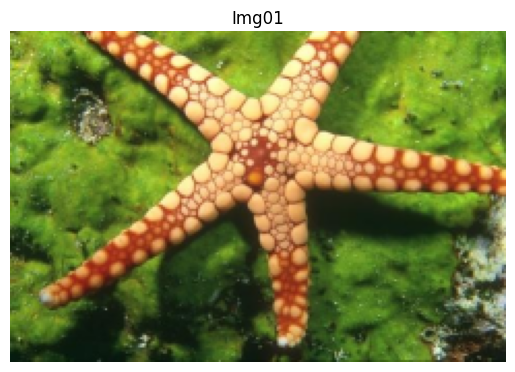

  Img01: scored against ['self', 'Nihal']

Saved 12 rows -> /content/sample_data/sweep/all_results.csv  (gt_source distinguishes self vs peers)
Saved 12 macro rows -> /content/sample_data/sweep/macro_results.csv

Top 5 (self) by macro IoU:
                         tag      IoU       BF
               kmeans_rgb_k9 0.582491 0.453506
               kmeans_rgb_k5 0.489631 0.296503
               kmeans_rgb_k2 0.459211 0.209017
               kmeans_lab_k2 0.246597 0.000000
meanshift_lab_gaussian_bw1p5 0.246597 0.000000


In [ ]:
import os, numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt
from skimage.filters.rank import modal
from skimage.morphology import disk

# ============================ SETTINGS ============================
IMG_DIR   = '/content/sample_data/Images'        # folder with Img01.jpg ... Img10.jpg
OUT       = '/content/sample_data/sweep'
TEST_MODE   = True          # validate on 1 image first; set False for the full run
SAVE_OVERLAY = True
SAVE_IMAGES_SOURCES = ['self']      # only YOUR GT saves result images; peers = numbers only

EXT     = {'Img07': 'png', 'Img09': 'png'}
IMAGES  = [f'Img{i:02d}' for i in range(1, 11)]

# Your GT + each classmate's GT. Each folder holds Img01_gt.png, Img02_gt.png, ...
# A classmate who only annotated some images is fine — missing ones are skipped.
GT_SOURCES = [
    ('self',        '/content/sample_data/gt'),
    ('Nihal',  '/content/sample_data/gt_nihal'),
]

def find_file(folder, stem, exts=('jpg', 'jpeg', 'png', 'JPG', 'PNG')):
    for e in exts:
        p = os.path.join(folder, f"{stem}.{e}")
        if os.path.exists(p):
            return p
    return None

PAIRS = [(iid, find_file(IMG_DIR, iid)) for iid in IMAGES]


FEATURE_SPACES = [
    dict(name='rgb',         color='rgb'),                                              # colour alone
    dict(name='lab',         color='lab'),                                              # colour alone
    dict(name='hsv',         color='hsv'),                                              # colour alone
    dict(name='spatial',     spatial=True, spatial_weight=1.0),                         # spatial alone
    dict(name='texture',     texture=True, pca=True),                                   # texture alone
    dict(name='lab_spatial', color='lab', spatial=True, spatial_weight=0.5),            # combination
    dict(name='lab_texture', color='lab', texture=True, pca=True),                      # combination
    dict(name='all',         color='lab', spatial=True, spatial_weight=0.5,
                             texture=True, pca=True),                                   # combination
]
K_RANGE   = [2, 5, 9]
MS_SPACES = [dict(name='lab', color='lab'),
             dict(name='lab_texture', color='lab', texture=True, pca=True)]
MS_KERNELS, MS_BW = ['gaussian', 'epanechnikov'], [1.5, 3.0]




kmeans_configs    = [dict(method='kmeans', k=k, **fs)
                     for fs in FEATURE_SPACES for k in K_RANGE]
# print(kmeans_configs)
meanshift_configs = [dict(method='meanshift', kernel=ker, bandwidth=bw, **fs)
                     for fs in MS_SPACES for ker in MS_KERNELS for bw in MS_BW]
# print(meanshift_configs)
ALL_CONFIGS = kmeans_configs + meanshift_configs
RUN_PAIRS   = PAIRS
if TEST_MODE:
    RUN_PAIRS   = PAIRS[:1]
    ALL_CONFIGS = kmeans_configs[:4] + meanshift_configs[:2]
print(f"{len(RUN_PAIRS)} images x {len(ALL_CONFIGS)} configs, "
      f"GT sources: {[s for s, _ in GT_SOURCES]}")


os.makedirs(OUT, exist_ok=True)
bank, meta = build_gabor_bank()
save_gabor_bank_fig(bank, meta, f"{OUT}/_gabor_bank.png")          # filter bank (once)

rows = []
for iid, ip in RUN_PAIRS:
    img = load_image(ip)
    od  = f"{OUT}/{iid}"; os.makedirs(od, exist_ok=True)
    plt.imshow(img)
    plt.title(f"{iid}")
    plt.axis('off')
    plt.show()
    cv2.imwrite(f"{od}/_input.png", cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    save_gabor_resp_fig(img, bank, meta, f"{od}/_gabor_responses.png")    # convolution per image

    gts = {}                                                      # load every available GT
    for sname, sdir in GT_SOURCES:
        gp = find_file(sdir, f"{iid}_gt")
        if gp is None:
            continue
        g = load_gt_mask(gp, resize_to=img.shape[:2])
        gts[sname] = g
        cv2.imwrite(f"{od}/_gt_{sname}.png",
                    cv2.cvtColor(label_to_color(g), cv2.COLOR_RGB2BGR))
    if 'self' in gts:                                             # blend self vs each peer (req. 5b)
        for sname, g in gts.items():
            if sname != 'self':
                cv2.imwrite(f"{od}/_blend_self_vs_{sname}.png",
                            cv2.cvtColor(blend_contours(img, gts['self'], g), cv2.COLOR_BGR2RGB))

    for cfg in ALL_CONFIGS:
        seg = segment_only(img, cfg, bank)                        # cluster ONCE
        tag = make_tag(cfg)
        for sname, g in gts.items():                              # score against every GT
            matched, P, R, I, B = score(seg, g)
            rows.append(dict(image=iid, gt_source=sname, **cfg, tag=tag,
                             P=P, R=R, IoU=I, BF=B))
            if sname in SAVE_IMAGES_SOURCES:
                imgs = {'seg': matched}
                if SAVE_OVERLAY:
                    imgs['overlay'] = contour_overlay(img, matched)
                save_outputs(od, tag, **imgs)
    print(f"  {iid}: scored against {list(gts)}")


df = pd.DataFrame(rows)
df.to_csv(f"{OUT}/all_results.csv", index=False)

mc   = ['P', 'R', 'IoU', 'BF']
meta_cols = df.drop(columns=['image'] + mc).drop_duplicates(['tag', 'gt_source'])
macro = df.groupby(['tag', 'gt_source'], as_index=False)[mc].mean()
macro = meta_cols.merge(macro, on=['tag', 'gt_source'])
macro.to_csv(f"{OUT}/macro_results.csv", index=False)

print(f"\nSaved {len(df)} rows -> {OUT}/all_results.csv  (gt_source distinguishes self vs peers)")
print(f"Saved {len(macro)} macro rows -> {OUT}/macro_results.csv")
print("\nTop 5 (self) by macro IoU:")
m_self = macro[macro.gt_source == 'self']
print(m_self.sort_values('IoU', ascending=False)[['tag', 'IoU', 'BF']].head().to_string(index=False))